# Medical Aid Charges — Linear Regression Proof of Concept
**Client:** Prominent South African medical aid scheme
**Goal:** A sliding scale of charges based on age, sex, BMI, children, smoking habits and region.
**Dataset:** Kaggle insurance dataset (US-based, proof of concept only).

---
## Part 2 — Analysis Plan (succinct)

| Step | Plan |
|---|---|
| **a. EDA** | Check shape, dtypes, missing values, duplicates. Profile target (`charges`) distribution and skew. Visualise: charges histogram, boxplots by smoker, age/BMI scatter coloured by smoker, correlation heatmap. Drop duplicates. |
| **b. Feature selection** | One-hot encode `sex`, `smoker`, `region` (drop-first to avoid the dummy trap). Backward elimination on OLS p-values: remove features with p > 0.05 one at a time until all are significant. |
| **c. Train model** | 80/20 train/test split (`random_state=42` for reproducibility). `sklearn.LinearRegression` with **default hyperparameters** (`fit_intercept=True`) — OLS has a closed-form solution, so there is little to tune. |
| **d. Interpret & evaluate** | **R²** (variance explained), **MAE** (average error in $, robust to outliers), **RMSE** (penalises large misses). Residual plots to check assumptions. Coefficients read as $ impact per unit for the sliding scale. |
| **e. Report** | Client-facing report covering: data overview, cleaning outcomes, EDA visuals and patterns, model training approach, evaluation results, improvements made, and limitations (US data, ZAR conversion needed). |

## Part 3a — Exploratory Data Analysis

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')

# Load the dataset
df = pd.read_csv('insurance_dataset.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Basic structure: 1338 rows, 7 columns, no missing values
print(df.shape)
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isna().sum())

(1338, 7)
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
# Data cleaning: check for and remove duplicate rows
print(f"Duplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after cleaning: {df.shape}")

Duplicates found: 1
Shape after cleaning: (1337, 7)


In [ ]:
# Summary statistics of the numeric columns
# Note: charges range from ~$1.1k to ~$63.8k with mean $13.3k >> median $9.4k -> right skew
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


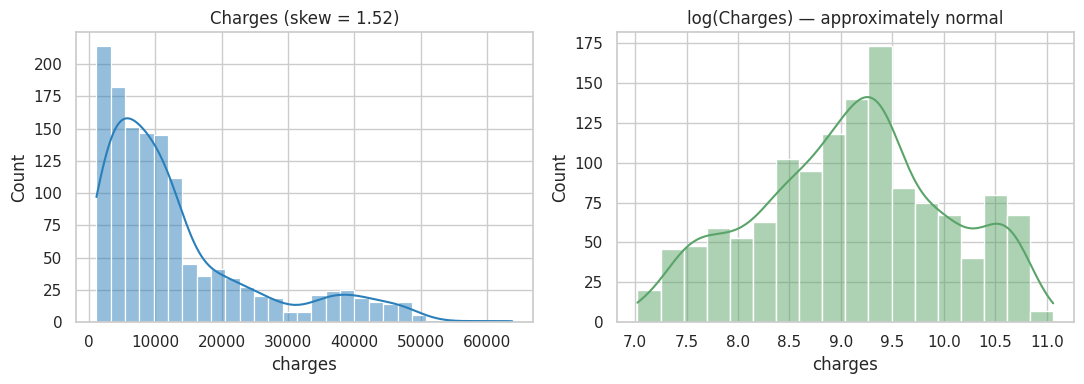

In [ ]:
# Target distribution: charges is right-skewed (skew ~1.5)
# A log transform makes it near-normal, useful to know for model assumptions
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['charges'], kde=True, ax=ax[0], color='#2a7fba')
ax[0].set_title(f"Charges (skew = {df['charges'].skew():.2f})")
sns.histplot(np.log(df['charges']), kde=True, ax=ax[1], color='#5aa469')
ax[1].set_title('log(Charges) — approximately normal')
plt.tight_layout(); plt.show()

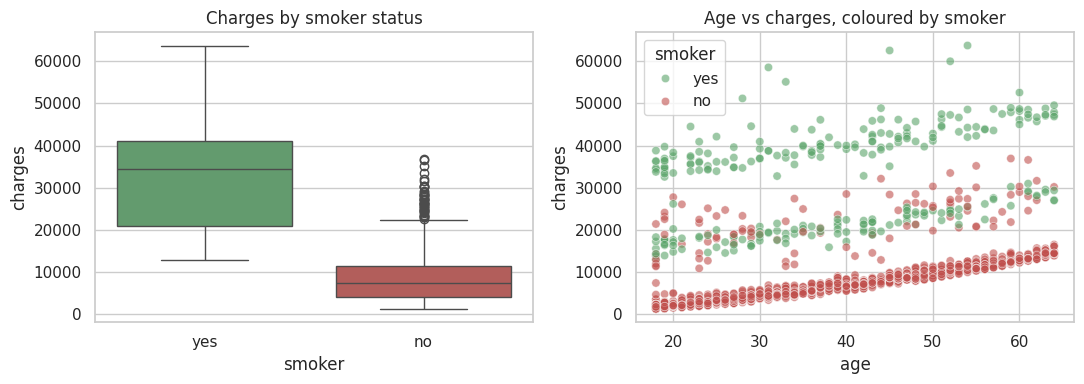

smoker
no      8441.0
yes    32050.0
Name: charges, dtype: float64


In [ ]:
# Smoking is the dominant cost driver: smokers average ~$32k vs ~$8.4k for non-smokers (~3.8x)
# The age scatter shows three distinct bands, separated by smoker status
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x='smoker', y='charges', ax=ax[0], hue='smoker',
            palette=['#5aa469','#c0504d'], legend=False)
ax[0].set_title('Charges by smoker status')
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6,
                ax=ax[1], palette=['#5aa469','#c0504d'])
ax[1].set_title('Age vs charges, coloured by smoker')
plt.tight_layout(); plt.show()

print(df.groupby('smoker')['charges'].mean().round(0))

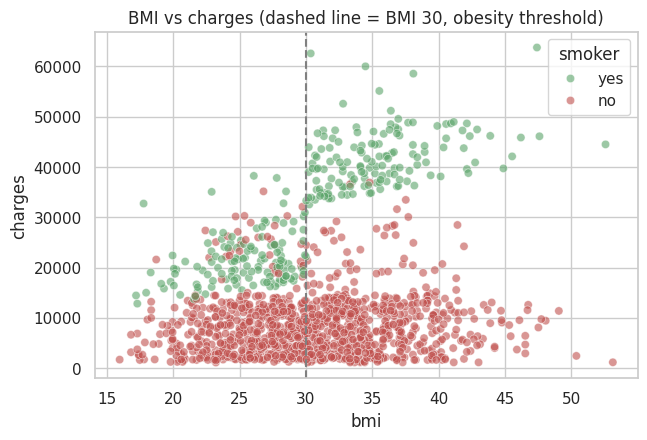

In [ ]:
# BMI matters mainly FOR SMOKERS: above BMI 30 (obesity), smoker charges jump sharply.
# This suggests an interaction effect we can exploit later to improve the model.
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6,
                palette=['#5aa469','#c0504d'])
plt.axvline(30, ls='--', c='gray')
plt.title('BMI vs charges (dashed line = BMI 30, obesity threshold)')
plt.show()

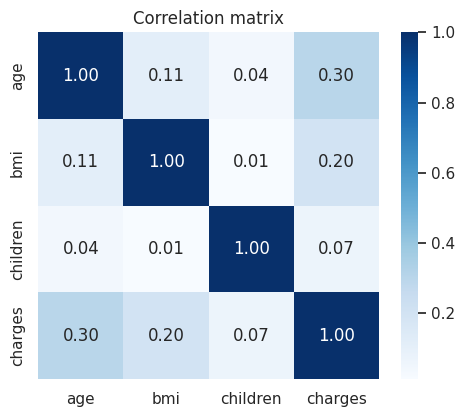

In [ ]:
# Correlations of numeric features with charges:
# age (0.30) and bmi (0.20) are moderate; children (0.07) is weak.
# No strong correlation BETWEEN predictors -> no multicollinearity concern.
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(df[['age','bmi','children','charges']].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation matrix')
plt.show()

In [ ]:
# Categorical breakdowns: sex and region differences are small compared to smoking
print(df.groupby('sex')['charges'].mean().round(0), "\n")
print(df.groupby('region')['charges'].mean().round(0))

sex
female    12570.0
male      13975.0
Name: charges, dtype: float64 

region
northeast    13406.0
northwest    12451.0
southeast    14735.0
southwest    12347.0
Name: charges, dtype: float64


**EDA conclusions:** data is clean (1 duplicate removed, no missing values). `smoker` is by far the strongest driver, followed by `age` and `bmi`. `sex` and `region` show small differences. Charges are right-skewed with a visible smoker×BMI interaction.

## Part 3b — Feature Selection (backward elimination on p-values)

In [ ]:
# One-hot encode the categorical columns.
# drop_first=True avoids the "dummy variable trap" (perfect multicollinearity).
df_enc = pd.get_dummies(df, columns=['sex','smoker','region'], drop_first=True, dtype=int)

X = df_enc.drop(columns='charges')
y = df_enc['charges']
list(X.columns)

['age',
 'bmi',
 'children',
 'sex_male',
 'smoker_yes',
 'region_northwest',
 'region_southeast',
 'region_southwest']

In [ ]:
# Backward elimination: fit OLS with ALL features, drop the feature with the
# highest p-value above alpha=0.05, refit, and repeat until all remaining
# features are statistically significant.
def backward_elimination(X, y, alpha=0.05):
    cols = list(X.columns)
    while True:
        model = sm.OLS(y, sm.add_constant(X[cols])).fit()
        pvals = model.pvalues.drop('const')
        if pvals.max() > alpha:
            worst = pvals.idxmax()
            print(f"Removing '{worst}' (p = {pvals.max():.4f})")
            cols.remove(worst)
        else:
            return cols, model

selected, ols_model = backward_elimination(X, y)
print("\nSelected features:", selected)

Removing 'sex_male' (p = 0.6976)
Removing 'region_northwest' (p = 0.4652)
Removing 'region_southwest' (p = 0.0582)
Removing 'region_southeast' (p = 0.1356)

Selected features: ['age', 'bmi', 'children', 'smoker_yes']


In [ ]:
# Final OLS summary: every retained feature has p < 0.05.
# sex and the region dummies were eliminated — consistent with the EDA.
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     996.5
Date:                Mon, 07 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:52:18   Log-Likelihood:                -13541.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1332   BIC:                         2.712e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.21e+04    942.630    -12.835      0.000   -1.39e+04   -1.02e+04
age          257.7728     11.910     21.644      0.000     234.409     281.137
bmi          321.8708     27.388     11.752      0.000     268.143     375.599
children     472.9751    137.879      3.430      0.001     202.492     743.458
smoker_yes  2.381e+04    411.414     57.875      0.000     2.3e+04    2.46e+04
==============================================================================
Omnibus:                      300.944   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              719.880
Skew:                           1.215   Prob(JB):                    4.79e-157
Kurtosis:                       5.650   Cond. No.                         292.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Feature selection result:** `age`, `bmi`, `children`, `smoker_yes` are retained. `sex_male` (p=0.70) and all three region dummies were eliminated — their effect on charges is not statistically significant once the other features are accounted for.

## Part 3c — Train the Model

In [ ]:
# 80/20 train/test split. random_state=42 makes the split reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X[selected], y, test_size=0.2, random_state=42)

# Hyperparameters: LinearRegression has a closed-form (OLS) solution, so we use
# the DEFAULTS: fit_intercept=True (learn a baseline charge), no regularisation.
lr = LinearRegression()
lr.fit(X_train, y_train)

# The learned sliding scale:
print(f"Intercept (baseline): {lr.intercept_:,.2f}")
print(pd.Series(lr.coef_, index=selected).round(2))

Intercept (baseline): -11,256.75
age             249.19
bmi             305.27
children        537.97
smoker_yes    23042.51
dtype: float64


**Interpretation of the sliding scale (Model 1):** each additional year of age adds ~\$249; each BMI point adds ~\$305; each child adds ~\$538; being a smoker adds ~\$23,000.

## Part 4a — Interpret and Evaluate the Model

In [ ]:
# Metric justification:
# - R^2: proportion of variance in charges the model explains (0-1, higher better)
# - MAE: average absolute error in dollars — easy for the client to understand
# - RMSE: like MAE but penalises large errors more — important because a few
#   very high charges could be badly mispriced.
def evaluate(model, X_te, y_te, label):
    pred = model.predict(X_te)
    print(f"{label}:  R2 = {r2_score(y_te, pred):.4f}"
          f"  MAE = {mean_absolute_error(y_te, pred):,.0f}"
          f"  RMSE = {np.sqrt(mean_squared_error(y_te, pred)):,.0f}")
    return pred

pred1 = evaluate(lr, X_test, y_test, "Model 1 (baseline)")

Model 1 (baseline):  R2 = 0.8046  MAE = 4,199  RMSE = 5,993


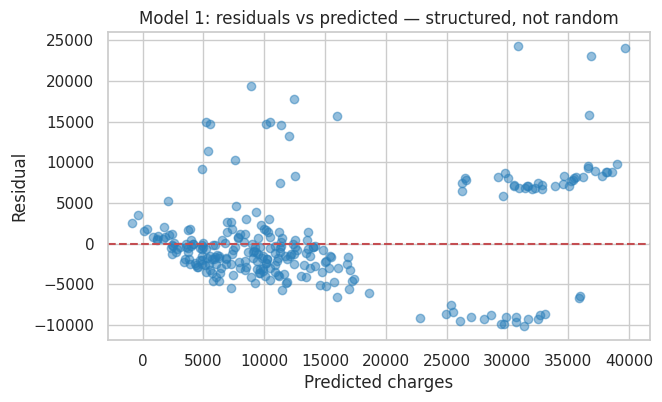

In [ ]:
# Residual analysis: the baseline model shows a clear curved/banded pattern in
# the residuals — it UNDERPREDICTS obese smokers and OVERPREDICTS others.
# This is the smoker x BMI interaction the EDA revealed.
resid1 = y_test - pred1
plt.figure(figsize=(7,4))
plt.scatter(pred1, resid1, alpha=0.5, color='#2a7fba')
plt.axhline(0, c='r', ls='--')
plt.xlabel('Predicted charges'); plt.ylabel('Residual')
plt.title('Model 1: residuals vs predicted — structured, not random')
plt.show()

## Part 4b — Retrain with Improvements

In [ ]:
# Shortcoming addressed: the linear model cannot capture that BMI only matters
# strongly for smokers. Fix: engineer interaction features.
df2 = df_enc.copy()
df2['obese'] = (df2['bmi'] >= 30).astype(int)          # clinical obesity flag
df2['smoker_bmi'] = df2['smoker_yes'] * df2['bmi']     # BMI effect for smokers only
df2['smoker_obese'] = df2['smoker_yes'] * df2['obese'] # obesity premium for smokers

feats2 = selected + ['obese', 'smoker_bmi', 'smoker_obese']
X2_train, X2_test, y2_train, y2_test = train_test_split(
    df2[feats2], y, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
pred2 = evaluate(lr2, X2_test, y2_test, "Model 2 (improved)")
print()
print(pd.Series(lr2.coef_, index=feats2).round(2))

Model 2 (improved):  R2 = 0.9068  MAE = 2,249  RMSE = 4,139

age               261.15
bmi               -40.43
children          572.23
smoker_yes       -241.74
obese             590.55
smoker_bmi        530.95
smoker_obese    14240.64
dtype: float64


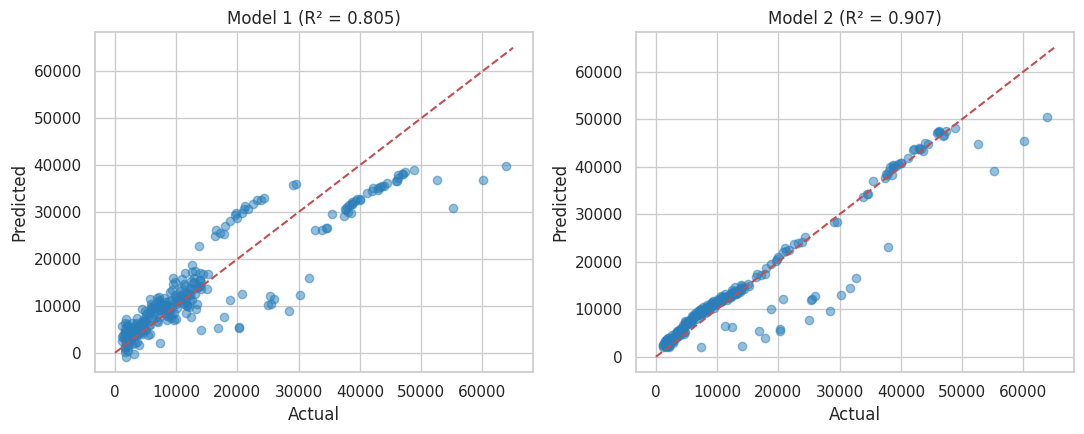

In [ ]:
# Side-by-side: actual vs predicted. Model 2 hugs the diagonal much more tightly.
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, p, yt, t in [(ax[0], pred1, y_test, 'Model 1'), (ax[1], pred2, y2_test, 'Model 2')]:
    a.scatter(yt, p, alpha=0.5, color='#2a7fba')
    a.plot([0, 65000], [0, 65000], 'r--')
    a.set_xlabel('Actual'); a.set_ylabel('Predicted')
    a.set_title(f"{t} (R² = {r2_score(yt, p):.3f})")
plt.tight_layout(); plt.show()

**Evaluation summary**

| Metric | Model 1 (baseline) | Model 2 (improved) |
|---|---|---|
| R² | 0.805 | **0.907** |
| MAE | \$4,199 | **\$2,249** |
| RMSE | \$5,993 | **\$4,139** |

Adding the smoker×BMI interaction features lifted variance explained from 80% to 91% and nearly halved the average error. The improved sliding scale: non-smokers pay ~\$261/year of age, ~\$572/child, and a small obesity loading; smokers pay an additional ~\$531 per BMI point plus a ~\$14,240 obesity premium.

**Limitations:** the dataset is US-based (dollar amounts and cost structures won't transfer directly to South Africa, this is a proof of concept only); residual heteroscedasticity remains; and in the SA regulatory context, medical schemes cannot legally rate premiums on health status, this model is for cost *analysis*, not open-ended premium discrimination.